In [7]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nltk.sentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np


path = r"C:\Users\Dania\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Attachments\Documents\GitHub\propositional-logic\ProyectoIA4.3\Amazon_Unlocked_Mobile.csv"

# Preprocesamiento

In [8]:
df1 = pd.read_csv(path)
df1 = df1.dropna(subset=["Reviews"]) 
Rating = df1["Rating"]
Reviews = df1["Reviews"]

def positivo_negativo(rating):
    return [1 if r >= 4 else 0 for r in rating]
df1["Nuevo Rating"] = positivo_negativo(Rating)

def reviewN(reviews):
    # TfidfVectorizer convierte texto en una matriz de características numéricas
    # donde cada palabra tiene un peso (TF-IDF) que refleja su importancia en el documento
    vectorizer = TfidfVectorizer()
    
    # Transformación del texto a representación numérica
    # fit_transform hace dos cosas:
    # Aprende el vocabulario
    # Transforma las reviews en una matriz sparse
    # El resultado es una matriz donde:
    # Cada fila representa una review
    # Cada columna representa una palabra del vocabulario
    # Cada celda contiene el valor TF-IDF de esa palabra en esa review
    tfidf_matrix = vectorizer.fit_transform(reviews)
    
    # Cálculo del valor numérico promedio por review
    # mean(axis=1) calcula el promedio de los valores TF-IDF para cada review (por fila)
    # Esto da un solo valor numérico que representa la "importancia promedio" de las palabras en cada review
    # getA1() convierte el resultado de formato matriz numpy a un array unidimensional
    numeric_values = tfidf_matrix.mean(axis=1).getA1()
    return numeric_values
df1["Review Numerico"] = reviewN(Reviews)
df1.reset_index(drop=True, inplace=True)
df1

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078
...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037
413768,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,I returned it because it did not meet my needs...,0.0,0,0.000053


In [9]:
#Se descarga una libreria extra (en caso de no contar con ella)
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Dania\AppData\Roaming\nltk_data...


True

In [10]:
#Se trabaja con sentiment Analyzer para diferenciar reviews positivas, negativas y neutras con un score
sia = SentimentIntensityAnalyzer()
results = {}

for row in df1.iterrows():
    text = row[1]["Reviews"]
    score = sia.polarity_scores(text)
    results[row[0]] = score

sentiment_score = pd.DataFrame(results).T

sentiment_score

,neg,neu,pos,compound
0,0.015,0.796,0.189,0.8783
1,0.072,0.597,0.331,0.9231
2,0.000,0.238,0.762,0.4927
3,0.000,0.500,0.500,0.9185
4,0.038,0.897,0.065,0.2942
...,...,...,...,...
413765,0.000,0.268,0.732,0.8481
413766,0.000,0.000,1.000,0.2960
413767,0.285,0.715,0.000,-0.3382
413768,0.000,0.806,0.194,0.5927


In [11]:
#Se agrega un label al index

sentiment_score.index.name = 'id'
sentiment_score

,neg,neu,pos,compound
id,,,,
0,0.015,0.796,0.189,0.8783
1,0.072,0.597,0.331,0.9231
2,0.000,0.238,0.762,0.4927
3,0.000,0.500,0.500,0.9185
4,0.038,0.897,0.065,0.2942
...,...,...,...,...
413765,0.000,0.268,0.732,0.8481
413766,0.000,0.000,1.000,0.2960
413767,0.285,0.715,0.000,-0.3382


In [12]:
#Se agrega un label al index
df1.index.name = "id"

df1

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico
id,,,,,,,,
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078
...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037


In [13]:
#uniendo los dataFrame
df_combined = df1.join(sentiment_score)

df_combined

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico,neg,neu,pos,compound
id,,,,,,,,,,,,
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102,0.015,0.796,0.189,0.8783
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074,0.072,0.597,0.331,0.9231
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020,0.000,0.238,0.762,0.4927
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046,0.000,0.500,0.500,0.9185
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078,0.038,0.897,0.065,0.2942
...,...,...,...,...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029,0.000,0.268,0.732,0.8481
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015,0.000,0.000,1.000,0.2960
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037,0.285,0.715,0.000,-0.3382


In [14]:
#Se cambia a numerica la variable de Brand Name

brands = df_combined['Brand Name'].unique()

for i, brand in enumerate(brands):
    df_combined.loc[df_combined["Brand Name"] == brand, "Brand"] = i+1

df_combined

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico,neg,neu,pos,compound,Brand
id,,,,,,,,,,,,,
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102,0.015,0.796,0.189,0.8783,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074,0.072,0.597,0.331,0.9231,1.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020,0.000,0.238,0.762,0.4927,1.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046,0.000,0.500,0.500,0.9185,1.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078,0.038,0.897,0.065,0.2942,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029,0.000,0.268,0.732,0.8481,1.0
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015,0.000,0.000,1.000,0.2960,1.0
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037,0.285,0.715,0.000,-0.3382,1.0


In [15]:
#Se filtran las columnas a usar
cols = ['Price', 'Review Votes', 'Review Numerico', 'pos', 'neu', 'neg', 'compound', 'Brand', 'Nuevo Rating']
data = df_combined[cols]


data.dropna(inplace=True)
print(f"Tamaño del dataset después de eliminar NaNs: {len(data)} filas")

data

Tamaño del dataset después de eliminar NaNs: 334328 filas


C:\Users\Dania\AppData\Local\Temp\ipykernel_40840\3116775519.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


,Price,Review Votes,Review Numerico,pos,neu,neg,compound,Brand,Nuevo Rating
id,,,,,,,,,
0,199.99,1.0,0.000102,0.189,0.796,0.015,0.8783,1.0,1
1,199.99,0.0,0.000074,0.331,0.597,0.072,0.9231,1.0,1
2,199.99,0.0,0.000020,0.762,0.238,0.000,0.4927,1.0,1
3,199.99,0.0,0.000046,0.500,0.500,0.000,0.9185,1.0,1
4,199.99,0.0,0.000078,0.065,0.897,0.038,0.2942,1.0,1
...,...,...,...,...,...,...,...,...,...
413765,79.95,0.0,0.000029,0.732,0.268,0.000,0.8481,1.0,1
413766,79.95,0.0,0.000015,1.000,0.000,0.000,0.2960,1.0,0
413767,79.95,0.0,0.000037,0.000,0.715,0.285,-0.3382,1.0,1


In [16]:
features = ['Price', 'Review Votes', 'Review Numerico', 'pos', 'neu', 'neg', 'compound', 'Brand']
X = data[features]
y = data['Nuevo Rating']

# División de datos en conjuntos de entrenamiento y prueba (estos son los datos NO ESCALADOS para DT/RF)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño de X_train (no escalado): {X_train.shape}")
print(f"Tamaño de X_test (no escalado): {X_test.shape}")

# Escalado de características (solo para uso de SVC) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

print(f"Tamaño de X_train_scaled (para SVC): {X_train_scaled.shape}")
print(f"Tamaño de X_test_scaled (para SVC): {X_test_scaled.shape}")

Tamaño de X_train (no escalado): (267462, 8)
Tamaño de X_test (no escalado): (66866, 8)
Tamaño de X_train_scaled (para SVC): (267462, 8)
Tamaño de X_test_scaled (para SVC): (66866, 8)


In [17]:
#Se hace el filtro para 30K de datos para el SVC
min_svc_train_size = 30000
current_train_size = len(X_train_scaled)

if current_train_size < min_svc_train_size:
    print(f"Advertencia: El tamaño del conjunto de entrenamiento escalado ({current_train_size}) es menor a {min_svc_train_size}.")
    print("Se utilizará el conjunto de entrenamiento escalado completo para SVC.")
    X_train_svc = X_train_scaled
    y_train_svc = y_train
    # Para la evaluación final del SVC, usamos el X_test_scaled principal
    X_test_svc = X_test_scaled
    y_test_svc = y_test
else:
    # Si el conjunto de entrenamiento es lo suficientemente grande, tomamos una muestra para SVC
    # Aseguramos un tamaño mínimo de 30k o el 10% del train set principal, lo que sea mayor, sin exceder el tamaño total.
    desired_svc_sample_size = min(current_train_size, max(min_svc_train_size, int(current_train_size * 0.1)))

    print(f"Tamaño original de X_train_scaled: {current_train_size}")
    print(f"Tomando una muestra de {desired_svc_sample_size} elementos (escalados) para SVC training...")

    # Tomamos la muestra deseada para SVC del conjunto de entrenamiento principal ESCALADO
    # El "_" se usa para ignorar el segundo conjunto de prueba que no necesitamos aquí
    X_svc_subset, _, y_svc_subset, _ = train_test_split(
        X_train_scaled, y_train, train_size=desired_svc_sample_size, random_state=42, stratify=y_train
    )
    # Dividimos esta submuestra en entrenamiento y prueba para SVC
    # (para la validación cruzada y evaluación final del SVC)
    X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(
        X_svc_subset, y_svc_subset, test_size=0.2, random_state=42, stratify=y_svc_subset
    )
    print(f"Tamaño de X_train_svc (para GridSearchCV): {len(X_train_svc)}")
    print(f"Tamaño de X_test_svc (para evaluación del modelo SVC): {len(X_test_svc)}")

Tamaño original de X_train_scaled: 267462
Tomando una muestra de 30000 elementos (escalados) para SVC training...
Tamaño de X_train_svc (para GridSearchCV): 24000
Tamaño de X_test_svc (para evaluación del modelo SVC): 6000


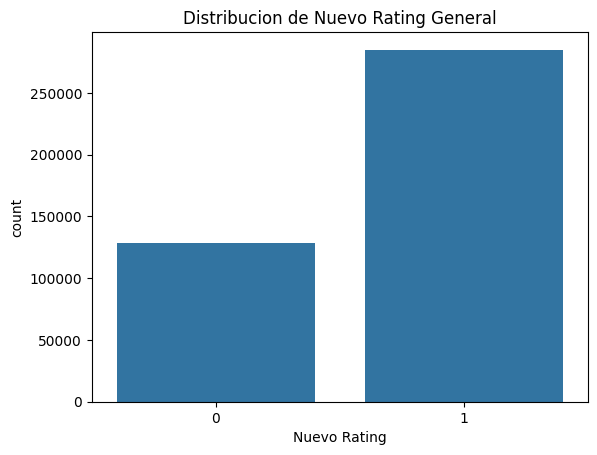

In [18]:
#Mostrando la distribucion de 0 y 1 dentro de la muestra elegida
plt.figure()
sns.countplot(data=df_combined, x="Nuevo Rating")
plt.title("Distribucion de Nuevo Rating General")
plt.show()

La gráfica muestra la distribución de la variable objetivo "Nuevo Rating", la cual fue transformada en una escala binaria donde los ratings originales iguales o superiores a 4 se clasifican como positivos (1) y los inferiores como negativos (0). Esta distribución indica que la mayoría de las valoraciones en el conjunto de datos original fueron altas, lo que podría reflejar una tendencia general hacia opiniones favorables en el dominio analizado.

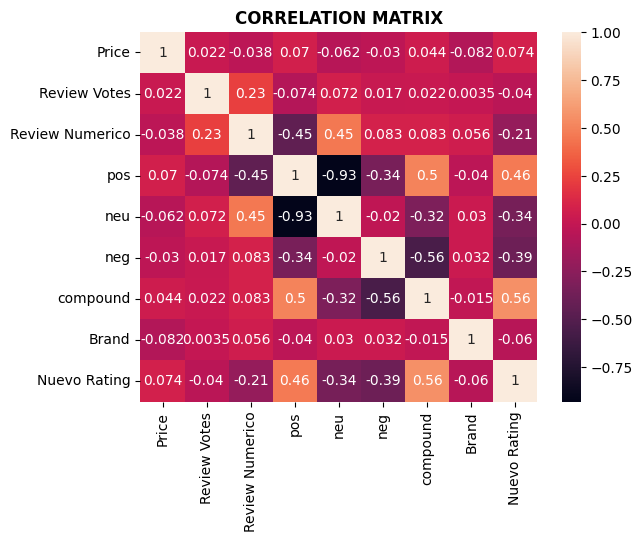

In [19]:
#Matiz de correlacion

plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title('CORRELATION MATRIX', fontweight='bold')
plt.show()
print("")

La matriz de correlación muestra las relaciones lineales entre las variables del conjunto de datos, destacando asociaciones significativas y patrones relevantes. Se observa una fuerte correlación negativa (-0.93) entre las variables "pos" y "neu", lo que indica que cuando una aumenta, la otra tiende a disminuir. La variable "compound", tiene una correlación moderadamente positiva (0.5) con "pos" y negativa (-0.56) con "neg", lo cual es consistente con su definición como indicador global de polaridad. En general, la matriz confirma que las variables de sentimiento ("pos", "neg", "compound") son las más relevantes para predecir el "Nuevo Rating", mientras que características como el precio o la marca ("Brand") tienen poca influencia lineal. Las correlaciones entre las demás variables son en su mayoría débiles o insignificantes, lo que reduce el riesgo de multicolinealidad en modelos predictivos.

# Implementación de modelos 

Se implementarán modelos de clasificación de Decision Tree, Random Forest y Support Vector Machine para predecir si un producto tiene una review buena o mala. Por lo que se intentará predecir la columna 'Nuevo Rating'

In [20]:
X = df_combined[['Price', 'Review Numerico', 'Review Votes', 'neg', 'neu', 'pos', 'compound', 'Brand']]
y = df_combined['Nuevo Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("N° of row in X_train: ", X_train.shape[0])
print("N° of row in X_test: ", X_test.shape[0])
print("N° of row in y_train: ", y_train.shape[0])
print("N° of row in y_test: ", y_test.shape[0])

N° of row in X_train:  331016
N° of row in X_test:  82754
N° of row in y_train:  331016
N° of row in y_test:  82754


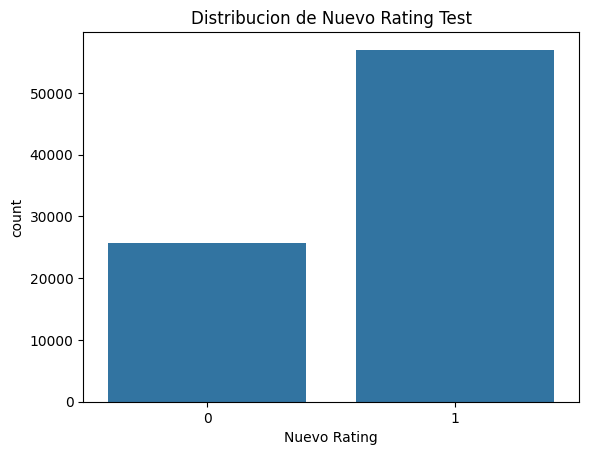

In [21]:
#Mostrando la distribucion de 0 y 1 dentro de Test
test = pd.DataFrame(y_test)
plt.figure()
sns.countplot(data=test, x="Nuevo Rating")
plt.title("Distribucion de Nuevo Rating Test")
plt.show()

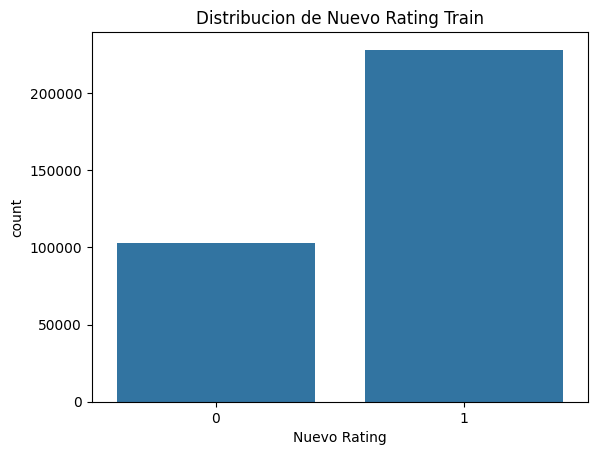

In [22]:
#Mostrando la distribucion de 0 y 1 dentro de Train
train = pd.DataFrame(y_train)
plt.figure()
sns.countplot(data=train, x="Nuevo Rating")
plt.title("Distribucion de Nuevo Rating Train")
plt.show()

### Decision Tree - Manual


In [23]:
#Realizando el modelo Decision Tree Classifier de manera manual
dt_classifier = DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, random_state=42)
dt_classifier.fit(X_train, y_train)

# Predicciones
y_pred_dt_train = dt_classifier.predict(X_train)
y_pred_dt_test = dt_classifier.predict(X_test)

In [24]:
# Evaluación del entrenamiento
print("Resultados de Decision Tree en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_dt_train))

Resultados de Decision Tree en Entrenamiento:
Accuracy: 0.8613
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.77    103058
           1       0.89      0.91      0.90    227958

    accuracy                           0.86    331016
   macro avg       0.84      0.83      0.84    331016
weighted avg       0.86      0.86      0.86    331016



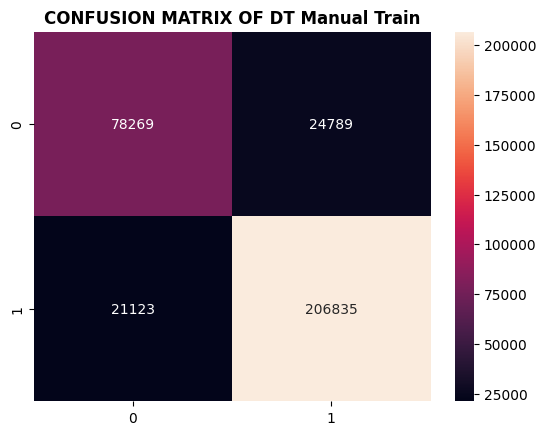

In [25]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_dt_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT Manual Train', fontweight='bold')
plt.show()

In [26]:
# Evaluación del test
print("Resultados de Decision Tree en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_test))

Resultados de Decision Tree en Test:
Accuracy: 0.8496
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75     25764
           1       0.88      0.90      0.89     56990

    accuracy                           0.85     82754
   macro avg       0.83      0.82      0.82     82754
weighted avg       0.85      0.85      0.85     82754



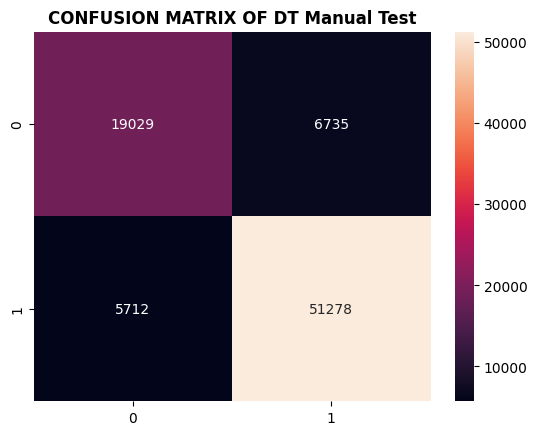

In [27]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_dt_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT Manual Test', fontweight='bold')
plt.show()

El modelo Decision Tree muestra un rendimiento consistente entre los conjuntos de entrenamiento y prueba, con un accuracy del 86.1% y 85.0% respectivamente, lo que indica una buena capacidad de generalización sin sobreajuste. Sin embargo, se observa un desempeño desigual entre las clases: mientras que para la clase mayoritaria (1) mantiene métricas sólidas (precision/recall ~88-90%), para la clase minoritaria (0) los resultados son más modestos (~74-77% en recall y precision), reflejando las dificultades, las métricas macro (82-83%) confirman que, aunque el modelo no ignora completamente la clase minoritaria, su efectividad para identificar casos negativos sigue siendo limitada. Esta brecha de rendimiento entre clases persiste tanto en entrenamiento como en prueba, sugiriendo que el problema fundamental radica en la distribución desigual de las clases más que en la capacidad predictiva del modelo como tal.

### Decision Tree - GridSearch

In [28]:
dt_classifier = DecisionTreeClassifier()
param_dt_classif = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [10, 12, 20],
    'min_samples_leaf': [5, 10, 15] 
}

grid_search_dt = GridSearchCV(estimator=dt_classifier, param_grid=param_dt_classif, cv=5, verbose=1)
grid_search_dt.fit(X_train, y_train)
best_class_dt = grid_search_dt.best_estimator_

best_class_dt

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\Dania\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


DecisionTreeClassifier(max_depth=20, min_samples_leaf=5)

In [29]:
# Predicciones
y_pred_dt_train = best_class_dt.predict(X_train)
y_pred_dt_test = best_class_dt.predict(X_test)

In [30]:
# Evaluación del entrenamiento
print("Resultados de Decision Tree en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_dt_train))

Resultados de Decision Tree en Entrenamiento:
Accuracy: 0.9186
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87    103058
           1       0.94      0.94      0.94    227958

    accuracy                           0.92    331016
   macro avg       0.90      0.91      0.91    331016
weighted avg       0.92      0.92      0.92    331016



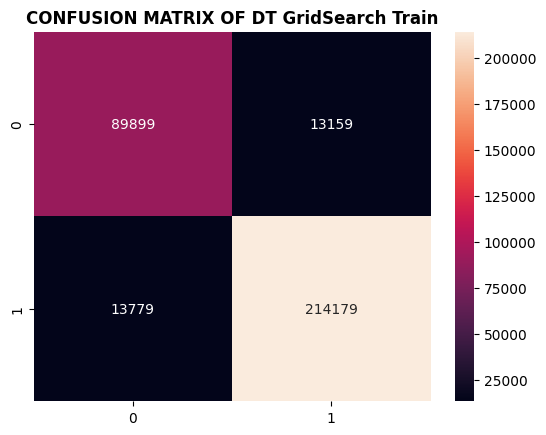

In [31]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_dt_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT GridSearch Train', fontweight='bold')
plt.show()

In [32]:
# Evaluación del test
print("Resultados de Decision Tree en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_test):.4f}")
print("Classification Report:")
report_dt_test = classification_report(y_test, y_pred_dt_test)
print(report_dt_test)

Resultados de Decision Tree en Test:
Accuracy: 0.8713
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.79     25764
           1       0.90      0.91      0.91     56990

    accuracy                           0.87     82754
   macro avg       0.85      0.85      0.85     82754
weighted avg       0.87      0.87      0.87     82754



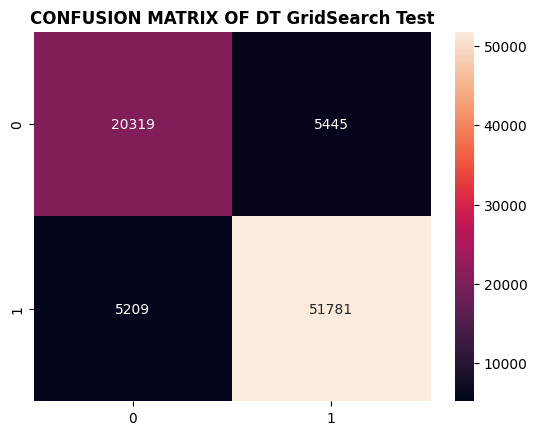

In [33]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_dt_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT GridSearch Test', fontweight='bold')
plt.show()

El modelo Decision Tree muestra un rendimiento sólido pero con diferencias significativas entre entrenamiento y prueba. En entrenamiento alcanza un accuracy del 91.86% con métricas balanceadas (F1-score: 0.94 para clase 1 y 0.87 para clase 0), demostrando su capacidad para aprender los patrones dominantes. Sin embargo, en prueba el accuracy baja al 87.13%, con una caída más pronunciada en la clase minoritaria (F1-score de 0.79 vs 0.91 para la clase mayoritaria). La brecha del 12% en efectividad entre clases (79% vs 91%) y la diferencia del 4.73% en accuracy entre conjuntos confirman que, aunque el modelo generaliza razonablemente bien, sigue presentando dificultades para manejar equitativamente ambas categorías, particularmente en la identificación consistente de casos negativos.

### Random Forest - Manual


In [34]:
rf_classifier = RandomForestClassifier(max_depth=12, min_samples_leaf=10, random_state=42)
rf_classifier.fit(X_train, y_train)

# Predicciones
y_pred_rf_train = rf_classifier.predict(X_train)
y_pred_rf_test = rf_classifier.predict(X_test)

In [35]:
# Evaluación del entrenamiento de Random Forest
print("Resultados de Random Forest en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_rf_train))

Resultados de Random Forest en Entrenamiento:
Accuracy: 0.8632
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78    103058
           1       0.89      0.91      0.90    227958

    accuracy                           0.86    331016
   macro avg       0.84      0.84      0.84    331016
weighted avg       0.86      0.86      0.86    331016



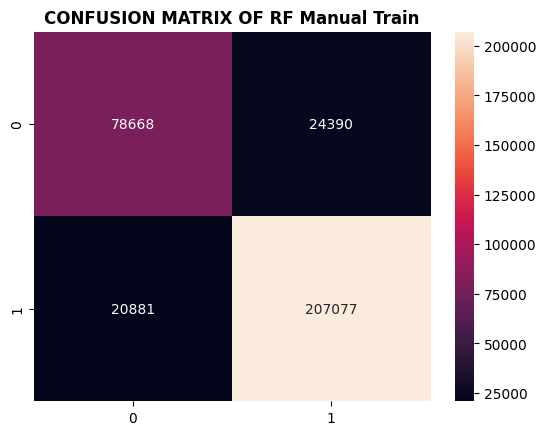

In [36]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_rf_train), annot=True, fmt='g') 
plt.title('CONFUSION MATRIX OF RF Manual Train', fontweight='bold')
plt.show()

In [37]:
# Evaluación del test
print("Resultados de Random Forest en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_test))

Resultados de Random Forest en Test:
Accuracy: 0.8556
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76     25764
           1       0.89      0.90      0.90     56990

    accuracy                           0.86     82754
   macro avg       0.83      0.83      0.83     82754
weighted avg       0.85      0.86      0.85     82754



Text(0.5, 1.0, 'CONFUSION MATRIX OF RF Manual Test')

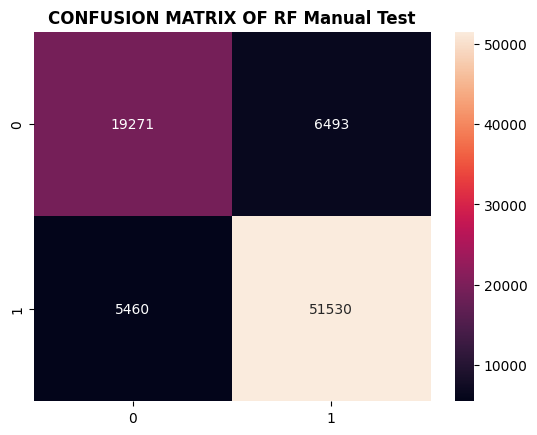

In [38]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_rf_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF RF Manual Test', fontweight='bold')

El modelo Random Forest muestra un comportamiento consistente y ligeramente superior al Decision Tree, manteniendo un buen equilibrio entre los conjuntos de entrenamiento y prueba. Con un accuracy del 86.32% en entrenamiento y 85.56% en prueba, demuestra una capacidad de generalización robusta, con apenas un 0.76% de diferencia entre ambos conjuntos. La estabilidad en las métricas macro avg (0.84 → 0.83) confirma que el modelo maneja razonablemente bien ambas clases, aunque persiste una brecha del ~14% en efectividad entre ellas,si bien mejora marginalmente la generalización respecto al Decision Tree, sigue presentando limitaciones similares para clasificar consistentemente la clase minoritaria. La mínima variación entre conjuntos (especialmente en recall para la clase 0: 76% vs 75%) sugiere que el modelo no está sobreajustado y que las diferencias en rendimiento responden principalmente a la distribución natural de los datos.

### Random Forest - GridSearch

In [39]:
rf_classifier = RandomForestClassifier(random_state=42)
param_rf_classif = {
    'n_estimators': [100, 200],
    'max_depth': [10, 12, 20],
    'min_samples_leaf': [5, 10, 15]
}

grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_rf_classif, cv=5, verbose=1, n_jobs=-1)
grid_search_rf.fit(X_train, y_train)
best_class_rf = grid_search_rf.best_estimator_

best_class_rf

Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\Users\Dania\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=200,
                       random_state=42)

In [40]:
# Predicciones
y_pred_rf_train = best_class_rf.predict(X_train)
y_pred_rf_test = best_class_rf.predict(X_test)

In [41]:
# Evaluación del entrenamiento
print("Resultados de Random Forest en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_rf_train))

Resultados de Random Forest en Entrenamiento:
Accuracy: 0.9242
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88    103058
           1       0.94      0.95      0.95    227958

    accuracy                           0.92    331016
   macro avg       0.91      0.91      0.91    331016
weighted avg       0.92      0.92      0.92    331016



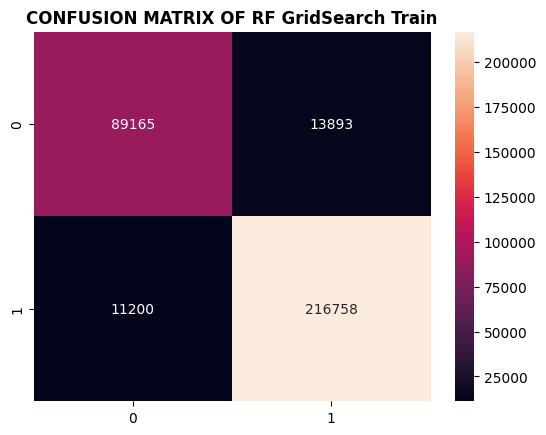

In [42]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_rf_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF RF GridSearch Train', fontweight='bold')
plt.show()

In [43]:
# Evaluación del test
print("Resultados de Random Forest en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_test):.4f}")
print("Classification Report:")
report_rf_test = classification_report(y_test, y_pred_rf_test)
print(report_rf_test)

Resultados de Random Forest en Test:
Accuracy: 0.8913
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82     25764
           1       0.91      0.93      0.92     56990

    accuracy                           0.89     82754
   macro avg       0.88      0.87      0.87     82754
weighted avg       0.89      0.89      0.89     82754



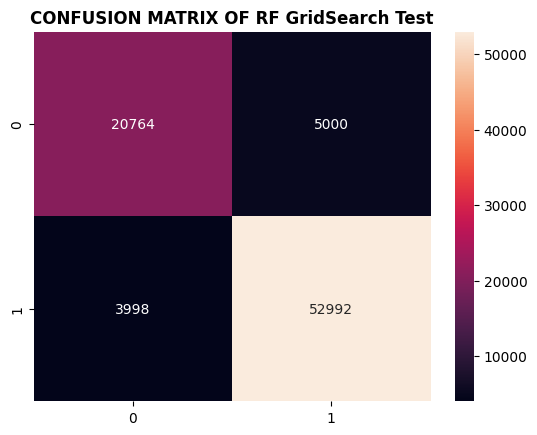

In [44]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_rf_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF RF GridSearch Test', fontweight='bold')
plt.show()

El modelo Random Forest muestra un rendimiento excepcional en el conjunto de entrenamiento, alcanzando un accuracy del 92.42% y métricas balanceadas en ambas clases. Para la clase minoritaria (0) obtiene un sólido F1-score de 0.88 (precision: 0.89, recall: 0.87), mientras que para la clase mayoritaria (1) logra un F1-score aún más alto de 0.95 (precision: 0.94, recall: 0.95). Estas cifras representan una mejora significativa respecto a versiones anteriores del modelo, particularmente en la clasificación de la clase minoritaria, donde el recall aumentó aproximadamente 11 puntos porcentuales (de 76% a 87%).

### SVC - Manual


In [45]:
svc_classifier = SVC(C=1.0, gamma='scale', kernel='rbf', random_state=42)
svc_classifier.fit(X_train_svc, y_train_svc)

# Predicciones
y_pred_svc_train = svc_classifier.predict(X_train_svc)
y_pred_svc_test = svc_classifier.predict(X_test_svc)

In [46]:
# Evaluación del entrenamiento de SVC
print("Resultados de SVC en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train_svc, y_pred_svc_train):.4f}")
print("Classification Report:")
print(classification_report(y_train_svc, y_pred_svc_train))

Resultados de SVC en Entrenamiento:
Accuracy: 0.8366
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.72      7442
           1       0.86      0.91      0.89     16558

    accuracy                           0.84     24000
   macro avg       0.82      0.79      0.80     24000
weighted avg       0.83      0.84      0.83     24000



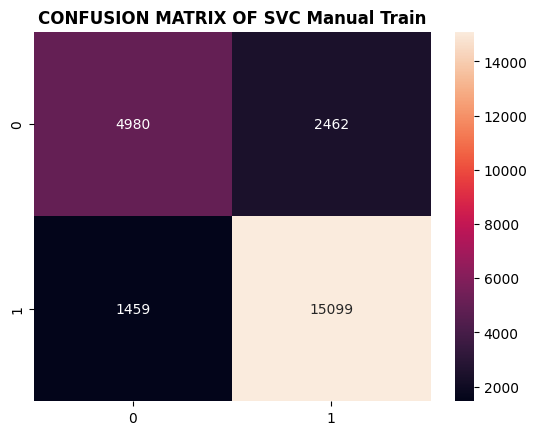

In [47]:
plt.figure()
sns.heatmap(confusion_matrix(y_train_svc, y_pred_svc_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF SVC Manual Train', fontweight='bold')
plt.show()

In [48]:
# Evaluación del test
print("Resultados de SVC en Test:")
print(f"Accuracy: {accuracy_score(y_test_svc, y_pred_svc_test):.4f}")
print("Classification Report:")
print(classification_report(y_test_svc, y_pred_svc_test))

Resultados de SVC en Test:
Accuracy: 0.8348
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.71      1860
           1       0.86      0.91      0.88      4140

    accuracy                           0.83      6000
   macro avg       0.81      0.79      0.80      6000
weighted avg       0.83      0.83      0.83      6000



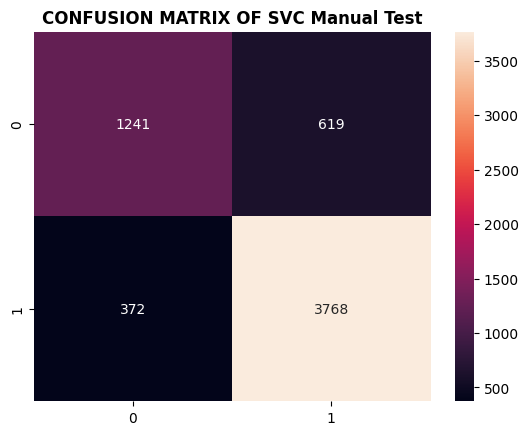

In [49]:
plt.figure()
sns.heatmap(confusion_matrix(y_test_svc, y_pred_svc_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF SVC Manual Test', fontweight='bold')
plt.show()

El modelo SVC muestra un rendimiento consistente pero con limitaciones significativas en el manejo del desbalanceo de clases. En ambos conjuntos (entrenamiento y prueba) mantiene un accuracy similar (~83.5%), lo que indica una adecuada capacidad de generalización. Sin embargo, se observa un claro desequilibrio en el desempeño por clases: mientras que para la clase mayoritaria (1) alcanza un F1-score de 0.89 (entrenamiento) y 0.88 (prueba), para la clase minoritaria (0) los resultados son notablemente inferiores (F1-score: 0.72 y 0.71 respectivamente). Esta brecha del ~17% en efectividad entre clases es particularmente evidente en el recall de la clase minoritaria (67% en ambos conjuntos), lo que indica que el modelo falla en identificar aproximadamente un tercio de los casos negativos. Estos resultados refuerzan la observación de que los modelos SVM/SVC, sin ajustes específicos para manejar clases desbalanceadas, tienden a favorecer a la clase mayoritaria, incluso cuando se aplica escalado de características.

### SVC - GridSearch

In [50]:
svc_classifier_gs = SVC(random_state=42)
param_svc_classif = { # Parámetros ajustados para SVC
    'C': [0.1, 1, 10],  # Parámetro de regularización
    'gamma': ['scale', 0.1, 1], # Coeficiente del kernel
    'kernel': ['rbf']
}

grid_search_svc_gs = GridSearchCV(estimator=svc_classifier_gs, param_grid=param_svc_classif, cv=3, verbose=2, n_jobs=-1, scoring='accuracy') # cv=3 para reducir el tiempo de GS del SVC

print(f"Iniciando GridSearchCV para SVC en {len(X_train_svc)} muestras (escaladas)...")
grid_search_svc_gs.fit(X_train_svc, y_train_svc) # Usando datos ESCALADOS

best_class_svc = grid_search_svc_gs.best_estimator_

best_class_svc

Iniciando GridSearchCV para SVC en 24000 muestras (escaladas)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


SVC(C=10, gamma=0.1, random_state=42)

In [51]:
# Predicciones
y_pred_svc_train = best_class_svc.predict(X_train_svc)
y_pred_svc_test = best_class_svc.predict(X_test_svc)

In [52]:
# Evaluación del entrenamiento
print("Resultados de SVC en Entrenamiento (GridSearchCV):")
print(f"Accuracy: {accuracy_score(y_train_svc, y_pred_svc_train):.4f}")
print("Classification Report:")
print(classification_report(y_train_svc, y_pred_svc_train))

Resultados de SVC en Entrenamiento (GridSearchCV):
Accuracy: 0.8396
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.68      0.73      7442
           1       0.86      0.91      0.89     16558

    accuracy                           0.84     24000
   macro avg       0.82      0.80      0.81     24000
weighted avg       0.84      0.84      0.84     24000



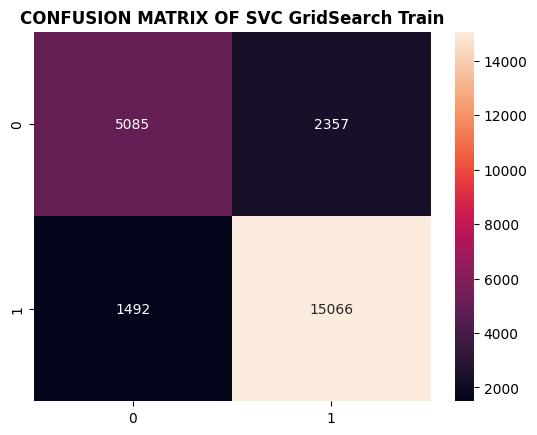

In [53]:
plt.figure()
sns.heatmap(confusion_matrix(y_train_svc, y_pred_svc_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF SVC GridSearch Train', fontweight='bold')
plt.show()

In [54]:
# Evaluación del test
print("Resultados de SVC en Test (GridSearchCV):")
print(f"Accuracy: {accuracy_score(y_test_svc, y_pred_svc_test):.4f}")
print("Classification Report:")
report_svc_test = classification_report(y_test_svc, y_pred_svc_test)
print(report_svc_test)

Resultados de SVC en Test (GridSearchCV):
Accuracy: 0.8367
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72      1860
           1       0.86      0.91      0.88      4140

    accuracy                           0.84      6000
   macro avg       0.81      0.79      0.80      6000
weighted avg       0.83      0.84      0.83      6000



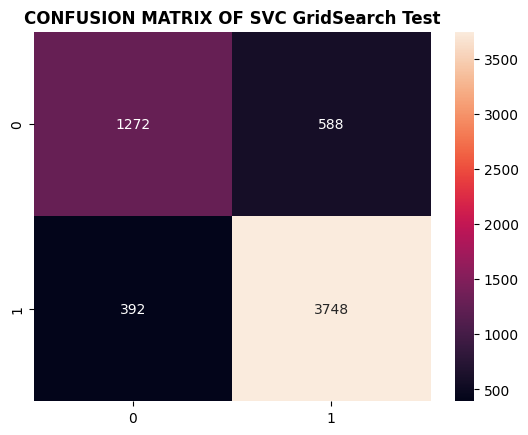

In [55]:
plt.figure()
sns.heatmap(confusion_matrix(y_test_svc, y_pred_svc_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF SVC GridSearch Test', fontweight='bold')
plt.show()

El modelo SVC optimizado mediante GridSearchCV muestra una mejora marginal pero consistente respecto a la versión manual, manteniendo el mismo patrón de comportamiento entre clases. Con un accuracy de 83.96% en entrenamiento y 83.67% en prueba (diferencia de solo 0.29 puntos), el modelo demuestra una excelente capacidad de generalización. La consistencia casi perfecta entre métricas de train y test (con variaciones <1% en todas las métricas clave) indica que el modelo está bien calibrado, pero alcanzó un "techo" de desempeño impuesto por la distribución natural de las clases.

In [56]:
#Mostrando las comparaciones de los 3 modelos del GridSearch

print("Report Decision Tree: ")
print(report_dt_test)
print("Report Random Forest: ")
print(report_rf_test)
print("Report Support Vector Machine: ")
print(report_svc_test)

Report Decision Tree: 
              precision    recall  f1-score   support

           0       0.80      0.79      0.79     25764
           1       0.90      0.91      0.91     56990

    accuracy                           0.87     82754
   macro avg       0.85      0.85      0.85     82754
weighted avg       0.87      0.87      0.87     82754

Report Random Forest: 
              precision    recall  f1-score   support

           0       0.84      0.81      0.82     25764
           1       0.91      0.93      0.92     56990

    accuracy                           0.89     82754
   macro avg       0.88      0.87      0.87     82754
weighted avg       0.89      0.89      0.89     82754

Report Support Vector Machine: 
              precision    recall  f1-score   support

           0       0.76      0.68      0.72      1860
           1       0.86      0.91      0.88      4140

    accuracy                           0.84      6000
   macro avg       0.81      0.79      0.80      6

In [57]:
def get_format_metrics(report: str):
    """Le da formato a classification_report() que genera un string

    Args:
        report (str): El string que devuelve classification_report()

    Returns:
        res: DataFrame con precision, recall y f1-score para 1 y 0
        accuracy: Accuracy del modelo 

    """
    rows = report.split("\n")
    names = rows[0].split()
    names.insert(0, "Type")
    names.pop(4)

    res = pd.DataFrame(columns=names)
    for row in rows[2:4]:
        vals = row.split()
        res.loc[-1] = vals[:-1]
        res.index = res.index + 1
        res = res.sort_index()
    #The accuracy
    accuracy = rows[5].split()[1]
    return res, float(accuracy)

In [58]:
#Formating the results
metrics_dt, acc_dt = get_format_metrics(report_dt_test)
metrics_rf, acc_rf = get_format_metrics(report_rf_test)
metrics_svc, acc_svc = get_format_metrics(report_svc_test)

metrics_dt["Model"] = "DT"
metrics_rf["Model"] = "RF"
metrics_svc["Model"] = "SVC"
#Doing the general dataframe with all the metrics
metrics_gral = pd.concat([metrics_dt, metrics_svc, metrics_rf], ignore_index=True)

df_melted = metrics_gral.melt(
    id_vars=['Model', 'Type'],
    value_vars=['precision', 'recall', 'f1-score'],
    var_name='Metric',
    value_name='Score'
)
df_melted = df_melted.astype({'Score':float})


<Figure size 640x480 with 0 Axes>

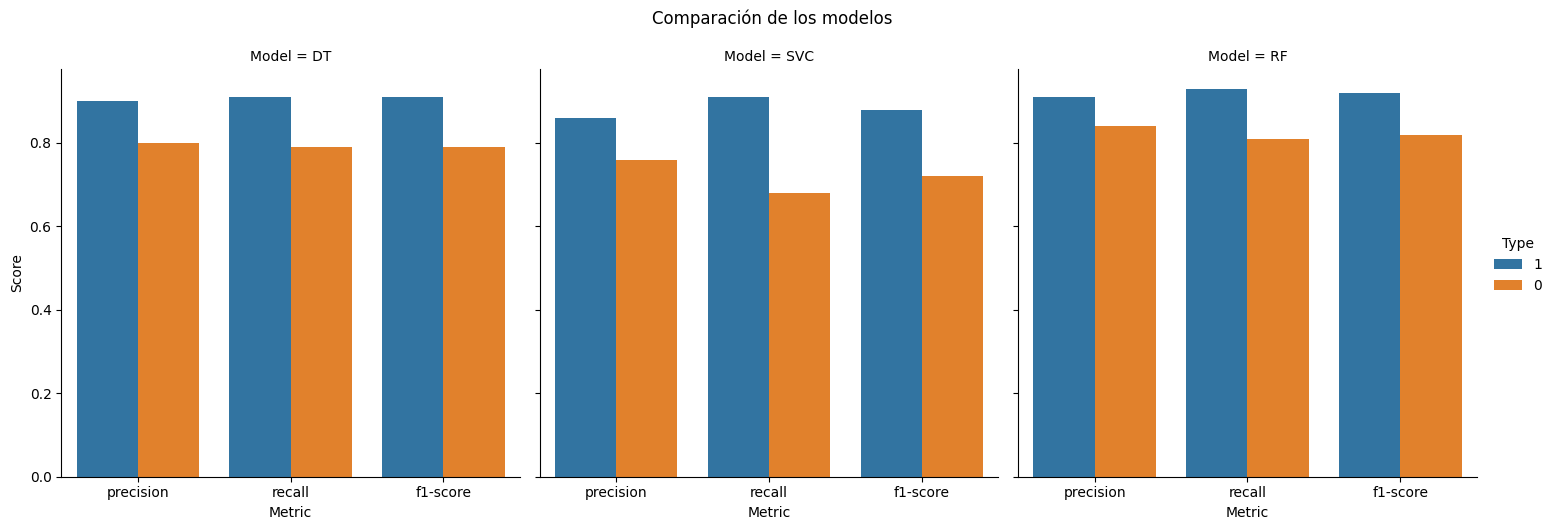

In [59]:
plt.figure()
g = sns.catplot(data=df_melted,x='Metric', y='Score', hue='Type', col='Model', kind='bar')
plt.suptitle("Comparación de los modelos", y=1.05)
plt.show()

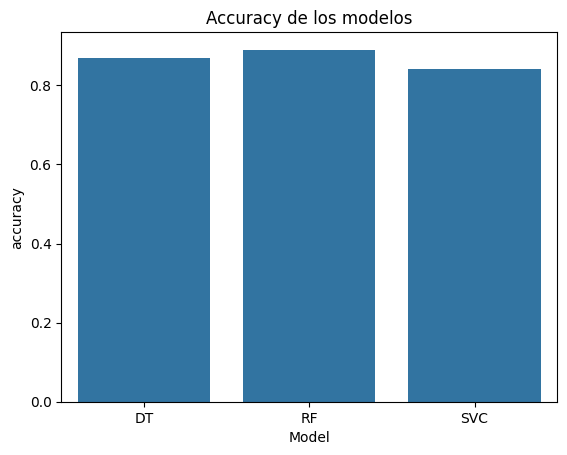

In [60]:
df_acc = pd.DataFrame({
    'Model':['DT', 'RF', 'SVC'],
    "accuracy":[acc_dt, acc_rf, acc_svc]
})

plt.figure()
sns.barplot(df_acc, x="Model", y='accuracy')
plt.title("Accuracy de los modelos")
plt.show()

### Conclusión

La comparación de los tres modelos optimizados (Decision Tree, Random Forest y SVC) revela diferencias significativas en su desempeño. El Random Forest (RF) emerge como el mejor clasificador, con un accuracy del 89% y métricas balanceadas para ambas clases (F1-score: 0.92 para clase 1 y 0.82 para clase 0), demostrando su capacidad para manejar el desbalanceo mejor que los demás. Le sigue el Decision Tree (DT) con 87% de accuracy y F1-scores de 0.91 (clase 1) y 0.79 (clase 0), mostrando un rendimiento sólido pero con mayor brecha entre clases. El SVC, aunque con un accuracy aceptable (84%), presenta la mayor disparidad: mientras alcanza 0.88 de F1-score para la clase mayoritaria, solo logra 0.72 para la minoritaria, evidenciando limitaciones para clasificar casos negativos. 

La gráfica de métricas por clase confirma que el RF no solo tiene el mayor accuracy, sino también la menor brecha entre precision y recall en ambas categorías, especialmente en la clase minoritaria (precision: 84%, recall: 81%). En contraste, el SVC muestra un recall particularmente bajo (68%) para la clase 0, lo que sugiere que ignora muchos casos negativos. El DT, por su parte, se ubica en un punto intermedio, con métricas más equilibradas que el SVC pero sin superar al RF. Estos resultados destacan la superioridad del Random Forest para problemas con desbalanceo moderado, donde mantener un buen equilibrio entre sensibilidad y especificidad es crucial. La consistencia del RF en ambas clases (macro avg: 0.87) lo convierte en la opción más robusta para este escenario.